# Robustness-aware multi-task brain tumor MRI
**Segmentation-guided tumor classification on the Figshare brain tumor dataset, evaluated with patient-level splits, perturbations, adversarial attacks and MC-dropout uncertainty.**

What this notebook does
1. Loads the Figshare dataset (3064 T1-CE slices, 233 patients; labels, patient IDs and tumor masks).
2. Trains a modular multi-task U-Net (swappable pretrained encoder, optional attention gates, optional mask-guided classification head).
3. Compares **patient-level** vs **slice-level** splits (quantifies the leakage in slice-shuffled protocols).
4. Stress-tests every model: Gaussian noise, bias field, gamma shift, FGSM, PGD.
5. Measures calibration and MC-dropout uncertainty (can uncertainty flag attacked / failing inputs?).
6. Ablations: baseline vs +attention vs +mask guidance vs full; plus a fast-FGSM adversarially trained variant.

**Before running:** Add the Figshare brain tumor dataset as an input (must contain the `.mat` files with `PID` and `tumorMask`), set the accelerator to a GPU, and turn Internet ON (for ImageNet weights).
Set `QUICK = True` in the next cell for a ~5 minute smoke test first.

## 0. Setup and configuration

In [1]:
import os, glob, json, math, time, random, warnings
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import cv2
import h5py
import scipy.io as sio
from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    display  # defined inside Jupyter/Kaggle
except NameError:
    display = print

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = DEVICE.type == "cuda"
torch.backends.cudnn.benchmark = True
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device", DEVICE)

# ---------------------------------------------------------------- CONFIG
QUICK = False  # True = 2-epoch smoke test on a small subset. Run this first!

CFG = dict(
    img_size=256,
    n_folds=5,
    folds_to_run=[0],        # e.g. [0,1,2,3,4] for full cross-validation (run across sessions; finished runs are skipped)
    seed=42,
    epochs=30,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    lambda_cls=1.0,          # weight of classification loss
    pretrained=True,         # ImageNet weights (needs Internet ON); falls back to random init if download fails
    adv_train_eps=2 / 255,   # for the fast-FGSM adversarially trained variant
    eval_eps=[1 / 255, 2 / 255, 4 / 255],
    pgd_steps=10,
    mc_samples=10,
    runs="all",              # "all" or a list of run names (see ALL_RUNS below)
)
if QUICK:
    CFG.update(epochs=2, patience=2, mc_samples=3, pgd_steps=3,
               runs=["resnet34_mt", "resnet34_mt_slicesplit"])

DATA_ROOT = os.environ.get("DATA_ROOT", "/kaggle/input")
WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./working")
OUT = WORK / "outputs"
for sub in ("results", "ckpt", "figs"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)


def seed_everything(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)


seed_everything(CFG["seed"])

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | device cuda


## 1. Data loading
Reads the original Figshare `.mat` files (MATLAB v7.3/HDF5, with a scipy fallback), extracts image, tumor mask, label and patient ID, resizes, and caches to one `.npz`.

In [3]:
def find_mat_files(root=DATA_ROOT):
    files = glob.glob(os.path.join(root, "**", "*.mat"), recursive=True)

    # Keep only numbered slice files: 1.mat, 2.mat, ..., 3064.mat
    files = [f for f in files if Path(f).stem.isdigit()]

    def key(p):
        pp = Path(p)
        return (str(pp.parent), 0, int(pp.stem)) if pp.stem.isdigit() else (str(pp.parent), 1, pp.stem)

    return sorted(files, key=key)


def load_mat(path):
    """Return image (float32), mask (uint8), label (1..3), pid (str)."""
    try:
        with h5py.File(path, "r") as f:
            d = f["cjdata"]
            img = np.array(d["image"]).T.astype(np.float32)
            mask = np.array(d["tumorMask"]).T.astype(np.uint8)
            label = int(np.array(d["label"]).squeeze())
            pid_arr = np.atleast_1d(np.array(d["PID"]).squeeze())
            pid = "".join(chr(int(c)) for c in pid_arr)
    except OSError:  # older (non-HDF5) MATLAB format
        s = sio.loadmat(path, squeeze_me=True, struct_as_record=False)["cjdata"]
        img = np.asarray(s.image).astype(np.float32)
        mask = np.asarray(s.tumorMask).astype(np.uint8)
        label = int(s.label)
        pid = str(s.PID)
    return img, mask, label, pid


def preprocess_image(img, size):
    lo, hi = np.percentile(img, (1, 99.5))
    if hi <= lo:
        hi = lo + 1.0
    img = np.clip((img - lo) / (hi - lo), 0, 1).astype(np.float32)
    interp = cv2.INTER_AREA if img.shape[0] > size else cv2.INTER_LINEAR
    return cv2.resize(img, (size, size), interpolation=interp)


def load_figshare(size):
    cache = WORK / f"figshare_{size}.npz"
    if cache.exists():
        z = np.load(cache, allow_pickle=False)
        print("Loaded cache", cache)
        return z["X"], z["M"], z["y"], z["pid"]
    files = find_mat_files()
    if not files:
        tree = "\n".join(sorted({str(Path(p).parent) for p in glob.glob(os.path.join(DATA_ROOT, "**", "*"), recursive=True)})[:30])
        raise FileNotFoundError(
            "No .mat files found under " + DATA_ROOT + ".\n"
            "This notebook needs the ORIGINAL Figshare files (cjdata struct with PID + tumorMask).\n"
            "Some Kaggle mirrors converted them to JPG/PNG and dropped patient IDs / masks - those cannot be used here.\n"
            "Directories seen:\n" + tree)
    print(f"Found {len(files)} .mat files, e.g. {files[0]}")
    X, M, Y, P = [], [], [], []
    for i, p in enumerate(files):
        img, mask, label, pid = load_mat(p)
        X.append(preprocess_image(img, size).astype(np.float16))
        M.append(cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST))
        Y.append(label - 1)
        P.append(pid)
        if (i + 1) % 500 == 0:
            print(f"  loaded {i + 1}/{len(files)}")
    X, M, Y, P = np.stack(X), np.stack(M), np.array(Y, dtype=np.int64), np.array(P)
    np.savez_compressed(cache, X=X, M=M, y=Y, pid=P)
    print("Saved cache", cache)
    return X, M, Y, P


X_np, M_np, Y_np, PIDS = load_figshare(CFG["img_size"])

if QUICK:
    sel = np.random.RandomState(0).choice(len(X_np), 600, replace=False)
    X_np, M_np, Y_np, PIDS = X_np[sel], M_np[sel], Y_np[sel], PIDS[sel]

CLASS_NAMES = ["meningioma", "glioma", "pituitary"]
print("slices:", len(X_np), "| patients:", len(np.unique(PIDS)), "| image tensor:", X_np.shape)
print("slices per class:", dict(zip(CLASS_NAMES, np.bincount(Y_np, minlength=3).tolist())))
n_lab = pd.Series(Y_np).groupby(PIDS).nunique()
print("patients with >1 label:", int((n_lab > 1).sum()), "(should be 0)")
print("mean tumor area fraction: %.3f" % M_np.mean())

# whole dataset lives on the GPU (small enough) -> fast training without DataLoader overhead
Xg = torch.from_numpy(X_np).to(DEVICE)
Mg = torch.from_numpy(M_np).to(DEVICE)
Yg = torch.from_numpy(Y_np).to(DEVICE)

Found 3064 .mat files, e.g. /kaggle/input/datasets/ashkhagan/figshare-brain-tumor-dataset/dataset/data/1.mat
  loaded 500/3064
  loaded 1000/3064
  loaded 1500/3064
  loaded 2000/3064
  loaded 2500/3064
  loaded 3000/3064
Saved cache /kaggle/working/figshare_256.npz
slices: 3064 | patients: 233 | image tensor: (3064, 256, 256)
slices per class: {'meningioma': 708, 'glioma': 1426, 'pituitary': 930}
patients with >1 label: 0 (should be 0)
mean tumor area fraction: 0.017


## 2. Splits: patient-level (correct) vs slice-level (leaky, as in many papers)

In [4]:
def make_split(mode, fold, n_folds=CFG["n_folds"], seed=CFG["seed"]):
    idx = np.arange(len(Y_np))
    if mode == "patient":
        sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        trainval, test = list(sgkf.split(idx, Y_np, groups=PIDS))[fold]
        sgkf2 = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=seed + 1)
        tr_i, va_i = next(iter(sgkf2.split(trainval, Y_np[trainval], groups=PIDS[trainval])))
        train, val = trainval[tr_i], trainval[va_i]
        assert not set(PIDS[test]) & set(PIDS[trainval]), "patient leakage in patient split!"
        assert not set(PIDS[val]) & set(PIDS[train]), "patient leakage between train and val!"
    elif mode == "slice":
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        trainval, test = list(skf.split(idx, Y_np))[fold]
        train, val = train_test_split(trainval, test_size=1 / 8, stratify=Y_np[trainval], random_state=seed)
    else:
        raise ValueError(mode)
    leak = float(np.isin(PIDS[test], PIDS[train]).mean())  # fraction of test slices whose patient is in train
    return dict(train=train, val=val, test=test, leak_frac=leak,
                n_test_patients=int(len(np.unique(PIDS[test]))))


for _m in ("patient", "slice"):
    s = make_split(_m, 0)
    print(f"{_m:7s} split | train {len(s['train'])} val {len(s['val'])} test {len(s['test'])} "
          f"| test slices whose patient is also in train: {100 * s['leak_frac']:.1f}%")

patient split | train 2106 val 313 test 645 | test slices whose patient is also in train: 0.0%
slice   split | train 2144 val 307 test 613 | test slices whose patient is also in train: 99.0%


## 3. Model: modular multi-task U-Net
* **Encoder**: ResNet34 / DenseNet121 / MobileNetV2 (three of the encoders benchmarked by DeepSeg), ImageNet-pretrained.
* **Decoder**: U-Net decoder, optional **attention gates** on skip connections.
* **Heads**: 1-channel tumor mask + 3-class tumor type.
* **Mask-guided classification**: the classifier also sees features pooled *inside the predicted tumor mask* (mask is detached, so it is a pure guidance signal).
* Dropout in the decoder and the classifier enables **MC-dropout** uncertainty.

In [5]:
def _build_tv(name, pretrained):
    ctor = getattr(torchvision.models, name)
    if pretrained:
        try:
            return ctor(weights="DEFAULT"), True
        except Exception as e:  # no internet etc.
            print(f"[warn] could not load pretrained weights for {name}: {type(e).__name__}. Using random init.")
    return ctor(weights=None), False


class Encoder(nn.Module):
    """Returns 5 feature maps at strides 2, 4, 8, 16, 32."""

    def __init__(self, name, pretrained=True):
        super().__init__()
        m, self.pretrained_loaded = _build_tv(name, pretrained)
        if name == "resnet34":
            self.stages = nn.ModuleList([
                nn.Sequential(m.conv1, m.bn1, m.relu),
                nn.Sequential(m.maxpool, m.layer1),
                m.layer2, m.layer3, m.layer4])
            self.channels = [64, 64, 128, 256, 512]
        elif name == "densenet121":
            f = list(m.features.children())
            self.stages = nn.ModuleList([
                nn.Sequential(*f[0:3]), nn.Sequential(*f[3:5]), nn.Sequential(*f[5:7]),
                nn.Sequential(*f[7:9]), nn.Sequential(*f[9:12])])
            self.channels = [64, 256, 512, 1024, 1024]
        elif name == "mobilenet_v2":
            f = m.features
            self.stages = nn.ModuleList([f[0:2], f[2:4], f[4:7], f[7:14], f[14:19]])
            self.channels = [16, 24, 32, 96, 1280]
        else:
            raise ValueError(name)

    def forward(self, x):
        outs = []
        for s in self.stages:
            x = s(x)
            outs.append(x)
        return outs


class ConvBNReLU(nn.Sequential):
    def __init__(self, i, o):
        super().__init__(nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))


class AttnGate(nn.Module):
    """Additive attention gate (Oktay et al. 2018) on a skip connection."""

    def __init__(self, g_ch, x_ch):
        super().__init__()
        inter = max(x_ch // 2, 8)
        self.wg = nn.Sequential(nn.Conv2d(g_ch, inter, 1, bias=False), nn.BatchNorm2d(inter))
        self.wx = nn.Sequential(nn.Conv2d(x_ch, inter, 1, bias=False), nn.BatchNorm2d(inter))
        self.psi = nn.Sequential(nn.Conv2d(inter, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())

    def forward(self, g, x):
        return x * self.psi(F.relu(self.wg(g) + self.wx(x)))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, attn, p_drop):
        super().__init__()
        self.attn = AttnGate(in_ch, skip_ch) if (attn and skip_ch > 0) else None
        self.conv = nn.Sequential(ConvBNReLU(in_ch + skip_ch, out_ch), nn.Dropout2d(p_drop), ConvBNReLU(out_ch, out_ch))

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        if skip is not None:
            if self.attn is not None:
                skip = self.attn(x, skip)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class MTNet(nn.Module):
    def __init__(self, enc="resnet34", pretrained=True, attn=True, guided=True, n_cls=3, p_dec=0.2, p_cls=0.5):
        super().__init__()
        self.guided = guided
        self.enc = Encoder(enc, pretrained)
        ch = self.enc.channels
        dec_ch = [256, 128, 64, 32, 16]
        skips = [ch[3], ch[2], ch[1], ch[0], 0]
        ins = [ch[4]] + dec_ch[:-1]
        self.dec = nn.ModuleList([DecoderBlock(i, s, o, attn, p_dec) for i, s, o in zip(ins, skips, dec_ch)])
        self.seg_head = nn.Conv2d(dec_ch[-1], 1, 1)
        if guided:
            self.proj = nn.Sequential(nn.Conv2d(ch[3], 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        cls_in = ch[4] + (128 if guided else 0)
        self.cls = nn.Sequential(nn.Dropout(p_cls), nn.Linear(cls_in, 256), nn.ReLU(inplace=True),
                                 nn.Dropout(p_cls), nn.Linear(256, n_cls))
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):  # x: (B,1,H,W) in [0,1]
        x3 = (x.expand(-1, 3, -1, -1) - self.mean) / self.std
        feats = self.enc(x3)
        d = feats[4]
        for blk, sk in zip(self.dec, [feats[3], feats[2], feats[1], feats[0], None]):
            d = blk(d, sk)
        seg = self.seg_head(d)
        g = feats[4].mean((2, 3))
        if self.guided:
            m = torch.sigmoid(seg).detach()
            m = F.interpolate(m, size=feats[3].shape[-2:], mode="bilinear", align_corners=False)
            f3 = self.proj(feats[3])
            mp = (f3 * m).sum((2, 3)) / (m.sum((2, 3)) + 1e-6)
            g = torch.cat([g, mp], dim=1)
        return seg, self.cls(g)


def enable_mc_dropout(model):
    model.eval()
    for mod in model.modules():
        if isinstance(mod, (nn.Dropout, nn.Dropout2d)):
            mod.train()


# quick shape check
_t = MTNet("resnet34", pretrained=False).to(DEVICE).eval()
with torch.no_grad():
    _s, _c = _t(torch.rand(2, 1, CFG["img_size"], CFG["img_size"], device=DEVICE))
print("shape check ->", tuple(_s.shape), tuple(_c.shape))
del _t, _s, _c

shape check -> (2, 1, 256, 256) (2, 3)


## 4. Losses, metrics, augmentation

In [10]:
def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * target).sum((1, 2, 3))
    den = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    return 1 - ((2 * inter + eps) / (den + eps)).mean()


def mt_loss(seg_logits, cls_logits, m, y, lam):
    seg = F.binary_cross_entropy_with_logits(seg_logits, m) + dice_loss(seg_logits, m)
    cls = F.cross_entropy(cls_logits, y)
    return seg + lam * cls, seg, cls


def seg_scores(prob, m, thr=0.5):
    p = (prob > thr).float()
    inter = (p * m).sum((1, 2, 3))
    sp, sm = p.sum((1, 2, 3)), m.sum((1, 2, 3))
    dice = (2 * inter + 1e-6) / (sp + sm + 1e-6)
    iou = (inter + 1e-6) / (sp + sm - inter + 1e-6)
    return dice, iou


def hd95(pred, gt):
    """95th percentile Hausdorff distance in pixels (bool arrays)."""
    diag = float(np.hypot(*pred.shape))
    if pred.sum() == 0 or gt.sum() == 0:
        return diag
    pb, gb = pred ^ binary_erosion(pred), gt ^ binary_erosion(gt)
    d_to_gt = distance_transform_edt(~gb)
    d_to_pred = distance_transform_edt(~pb)
    return float(np.percentile(np.concatenate([d_to_gt[pb], d_to_pred[gb]]), 95))


def ece_score(probs, labels, n_bins=15):
    conf, pred = probs.max(1), probs.argmax(1)
    correct = pred == labels
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        msk = (conf > lo) & (conf <= hi)
        if msk.any():
            ece += msk.mean() * abs(correct[msk].mean() - conf[msk].mean())
    return float(ece)


def nll_score(probs, labels):
    return float(-np.log(probs[np.arange(len(labels)), labels] + 1e-12).mean())


def gpu_augment(x, m):
    B, dev = x.shape[0], x.device
    flip = torch.rand(B, device=dev) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(-1), x)
    m = torch.where(flip[:, None, None, None], m.flip(-1), m)
    ang = (torch.rand(B, device=dev) * 2 - 1) * math.radians(15)
    sc = 1 + (torch.rand(B, device=dev) * 2 - 1) * 0.10
    tx = (torch.rand(B, device=dev) * 2 - 1) * 0.08
    ty = (torch.rand(B, device=dev) * 2 - 1) * 0.08
    cos, sin = torch.cos(ang) / sc, torch.sin(ang) / sc
    theta = torch.stack([torch.stack([cos, -sin, tx], 1), torch.stack([sin, cos, ty], 1)], 1)
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
    m = (F.grid_sample(m, grid, mode="bilinear", padding_mode="zeros", align_corners=False) > 0.5).float()
    c = 1 + (torch.rand(B, 1, 1, 1, device=dev) * 2 - 1) * 0.15
    b = (torch.rand(B, 1, 1, 1, device=dev) * 2 - 1) * 0.05
    return (x * c + b).clamp(0, 1), m

## 5. Perturbations and adversarial attacks
All images live in [0,1] and normalisation happens *inside* the model, so epsilon is in raw intensity units (2/255 ~ 0.8% of the intensity range).
Attacks are **white-box, untargeted**, against the *joint* loss (segmentation + classification) of the deterministic model.

In [11]:
def input_grad(model, x, m, y, amp=False):
    x = x.detach().clone().requires_grad_(True)
    with torch.enable_grad():
        with torch.autocast(DEVICE.type, enabled=(amp and AMP)):
            sl, cl = model(x)
        loss, _, _ = mt_loss(sl.float(), cl.float(), m, y, CFG["lambda_cls"])
        g, = torch.autograd.grad(loss * (1024.0 if amp else 1.0), x)
    return g


def p_noise(model, x, m, y, gen, sigma):
    return (x + sigma * torch.randn(x.shape, device=x.device, generator=gen)).clamp(0, 1)


def p_bias(model, x, m, y, gen, strength):
    B, _, H, W = x.shape
    coarse = torch.randn(B, 1, 4, 4, device=x.device, generator=gen)
    f = F.interpolate(coarse, size=(H, W), mode="bicubic", align_corners=False)
    f = f / (f.abs().amax((2, 3), keepdim=True) + 1e-6)
    return (x * (1 + strength * f)).clamp(0, 1)


def p_gamma(model, x, m, y, gen, g):
    return x.clamp(1e-6, 1) ** g


def p_fgsm(model, x, m, y, gen, eps):
    g = input_grad(model, x, m, y)
    return (x + eps * g.sign()).clamp(0, 1).detach()


def p_pgd(model, x, m, y, gen, eps, steps):
    alpha = 2.5 * eps / steps
    xa = (x + (torch.rand(x.shape, device=x.device, generator=gen) * 2 - 1) * eps).clamp(0, 1)
    for _ in range(steps):
        g = input_grad(model, xa, m, y)
        xa = xa + alpha * g.sign()
        xa = torch.min(torch.max(xa, x - eps), x + eps).clamp(0, 1).detach()
    return xa


def fast_fgsm_train(model, x, m, y, eps):
    """FGSM with random start (Wong et al. 2020) for adversarial training."""
    x0 = (x + (torch.rand_like(x) * 2 - 1) * eps).clamp(0, 1)
    g = input_grad(model, x0, m, y, amp=True)
    xa = x0 + 1.25 * eps * g.sign()
    return torch.min(torch.max(xa, x - eps), x + eps).clamp(0, 1).detach()


def build_perturbations():
    P = {"clean": None}
    for s in (0.02, 0.05, 0.10):
        P[f"noise_{s}"] = partial(p_noise, sigma=s)
    for s in (0.2, 0.4):
        P[f"bias_{s}"] = partial(p_bias, strength=s)
    for g in (0.7, 1.5):
        P[f"gamma_{g}"] = partial(p_gamma, g=g)
    for e in CFG["eval_eps"]:
        k = int(round(e * 255))
        P[f"fgsm_{k}"] = partial(p_fgsm, eps=e)
        P[f"pgd_{k}"] = partial(p_pgd, eps=e, steps=CFG["pgd_steps"])
    return P


PERTURBS = build_perturbations()
print("evaluation conditions:", list(PERTURBS))

evaluation conditions: ['clean', 'noise_0.02', 'noise_0.05', 'noise_0.1', 'bias_0.2', 'bias_0.4', 'gamma_0.7', 'gamma_1.5', 'fgsm_1', 'pgd_1', 'fgsm_2', 'pgd_2', 'fgsm_4', 'pgd_4']


## 6. Evaluation (accuracy, F1, patient-level accuracy, Dice, IoU, HD95, ECE, NLL) and MC-dropout uncertainty

In [12]:
def run_eval(model, idx, perturb=None, hd=False, bs=32, seed=1234):
    model.eval()
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    dices, ious, probs, hds = [], [], [], []
    for i in range(0, len(idx), bs):
        b = torch.as_tensor(idx[i:i + bs], device=DEVICE)
        x, m, y = Xg[b].float().unsqueeze(1), Mg[b].float().unsqueeze(1), Yg[b]
        if perturb is not None:
            x = perturb(model, x, m, y, gen)
        with torch.no_grad(), torch.autocast(DEVICE.type, enabled=AMP):
            sl, cl = model(x)
        sp = torch.sigmoid(sl.float())
        d, j = seg_scores(sp, m)
        dices.append(d.cpu().numpy())
        ious.append(j.cpu().numpy())
        probs.append(F.softmax(cl.float(), 1).cpu().numpy())
        if hd:
            pn, gn = (sp > 0.5).cpu().numpy()[:, 0], (m > 0.5).cpu().numpy()[:, 0]
            hds.extend(hd95(p_, g_) for p_, g_ in zip(pn, gn))
    out = dict(dice=np.concatenate(dices), iou=np.concatenate(ious), probs=np.concatenate(probs))
    if hd:
        out["hd95"] = np.array(hds)
    return out


def summarize(out, y, pids):
    probs = out["probs"]
    pred = probs.argmax(1)
    s = dict(
        dice=float(out["dice"].mean()), iou=float(out["iou"].mean()),
        acc=float((pred == y).mean()),
        f1=float(f1_score(y, pred, labels=[0, 1, 2], average="macro", zero_division=0)),
        ece=ece_score(probs, y), nll=nll_score(probs, y))
    df = pd.DataFrame(probs, columns=[0, 1, 2])
    df["pid"], df["y"] = pids, y
    g = df.groupby("pid").agg({0: "mean", 1: "mean", 2: "mean", "y": "first"})
    s["patient_acc"] = float((g[[0, 1, 2]].values.argmax(1) == g["y"].values).mean())
    if "hd95" in out:
        s["hd95"] = float(np.mean(out["hd95"]))
    return s


@torch.no_grad()
def mc_predict(model, x, T):
    enable_mc_dropout(model)
    ps, ss = [], []
    for _ in range(T):
        with torch.autocast(DEVICE.type, enabled=AMP):
            sl, cl = model(x)
        ps.append(F.softmax(cl.float(), 1))
        ss.append(torch.sigmoid(sl.float()))
    return torch.stack(ps).mean(0), torch.stack(ss).mean(0)


def _bin_entropy(S):
    return -(S * torch.log(S + 1e-12) + (1 - S) * torch.log(1 - S + 1e-12))


def uncertainty_eval(model, idx, eps=2 / 255, bs=32):
    T = CFG["mc_samples"]
    gen = torch.Generator(device=DEVICE).manual_seed(777)
    R = {k: dict(P=[], seg_unc=[], dice=[], y=[]) for k in ("clean", "adv")}
    for i in range(0, len(idx), bs):
        b = torch.as_tensor(idx[i:i + bs], device=DEVICE)
        x, m, y = Xg[b].float().unsqueeze(1), Mg[b].float().unsqueeze(1), Yg[b]
        model.eval()
        x_adv = p_pgd(model, x, m, y, gen, eps, CFG["pgd_steps"])
        for k, xx in (("clean", x), ("adv", x_adv)):
            Pm, Sm = mc_predict(model, xx, T)
            d, _ = seg_scores(Sm, m)
            R[k]["P"].append(Pm.cpu().numpy())
            R[k]["seg_unc"].append(_bin_entropy(Sm).mean((1, 2, 3)).cpu().numpy())
            R[k]["dice"].append(d.cpu().numpy())
            R[k]["y"].append(y.cpu().numpy())
    model.eval()
    A = {k: {kk: np.concatenate(v) for kk, v in R[k].items()} for k in R}
    U = {}
    for k in A:
        P, yy = A[k]["P"], A[k]["y"]
        ent = -(P * np.log(P + 1e-12)).sum(1)
        A[k]["ent"] = ent
        U[f"{k}_acc_mc"] = float((P.argmax(1) == yy).mean())
        U[f"{k}_dice_mc"] = float(A[k]["dice"].mean())
        U[f"{k}_ece_mc"] = ece_score(P, yy)
        U[f"{k}_nll_mc"] = nll_score(P, yy)
        U[f"{k}_mean_cls_entropy"] = float(ent.mean())
        U[f"{k}_mean_seg_entropy"] = float(A[k]["seg_unc"].mean())
    n = len(A["clean"]["ent"])
    lab = np.r_[np.zeros(n), np.ones(n)]
    U["auroc_detect_attack_cls_entropy"] = float(roc_auc_score(lab, np.r_[A["clean"]["ent"], A["adv"]["ent"]]))
    U["auroc_detect_attack_seg_entropy"] = float(roc_auc_score(lab, np.r_[A["clean"]["seg_unc"], A["adv"]["seg_unc"]]))
    err = A["clean"]["P"].argmax(1) != A["clean"]["y"]
    if err.any() and (~err).any():
        U["auroc_misclassification_cls_entropy"] = float(roc_auc_score(err, A["clean"]["ent"]))
    rho = spearmanr(A["clean"]["seg_unc"], 1 - A["clean"]["dice"]).correlation
    U["spearman_segentropy_vs_dice_error"] = float(rho) if rho == rho else None
    return U


def qualitative(model, test_idx, eps=2 / 255, per_class=2):
    ids = np.concatenate([test_idx[Y_np[test_idx] == c][:per_class] for c in range(3)])
    b = torch.as_tensor(ids, device=DEVICE)
    x, m, y = Xg[b].float().unsqueeze(1), Mg[b].float().unsqueeze(1), Yg[b]
    gen = torch.Generator(device=DEVICE).manual_seed(5)
    model.eval()
    x_adv = p_pgd(model, x, m, y, gen, eps, CFG["pgd_steps"])
    with torch.no_grad():
        sl, cl = model(x)
        sla, cla = model(x_adv)
    Pm, Sm = mc_predict(model, x, CFG["mc_samples"])
    model.eval()
    npy = lambda t: t.detach().float().cpu().numpy()
    return dict(x=npy(x)[:, 0], x_adv=npy(x_adv)[:, 0], m=npy(m)[:, 0], y=npy(y),
                seg_clean=npy(torch.sigmoid(sl))[:, 0], seg_adv=npy(torch.sigmoid(sla))[:, 0],
                unc=npy(_bin_entropy(Sm))[:, 0],
                cls_clean=npy(cl).argmax(1), cls_adv=npy(cla).argmax(1))

## 7. Training and experiment runner

In [13]:
def R_(name, enc="resnet34", attn=True, guided=True, split="patient", adv=False):
    return dict(name=name, enc=enc, attn=attn, guided=guided, split=split, adv=adv)


ALL_RUNS = [
    # main encoder comparison (DeepSeg-style modular encoders) with the full model
    R_("resnet34_mt"), R_("densenet121_mt", enc="densenet121"), R_("mobilenet_v2_mt", enc="mobilenet_v2"),
    # ablations (ResNet34)
    R_("resnet34_base", attn=False, guided=False), R_("resnet34_attn", attn=True, guided=False),
    R_("resnet34_guided", attn=False, guided=True),
    # adversarial training and the leaky split protocol
    R_("resnet34_mt_advtrain", adv=True), R_("resnet34_mt_slicesplit", split="slice"),
]
SEL_RUNS = ALL_RUNS if CFG["runs"] == "all" else [r for r in ALL_RUNS if r["name"] in CFG["runs"]]
print("runs:", [r["name"] for r in SEL_RUNS], "| folds:", CFG["folds_to_run"])


def train_run(run, split):
    model = MTNet(run["enc"], CFG["pretrained"], run["attn"], run["guided"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"])
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)
    tr, bs = split["train"], CFG["batch_size"]
    best, best_state, bad, hist = -1.0, None, 0, []
    for ep in range(CFG["epochs"]):
        t0 = time.time()
        model.train()
        perm = np.random.permutation(tr)
        losses = []
        for i in range(0, len(perm) - bs + 1, bs):
            b = torch.as_tensor(perm[i:i + bs], device=DEVICE)
            x, m, y = Xg[b].float().unsqueeze(1), Mg[b].float().unsqueeze(1), Yg[b]
            x, m = gpu_augment(x, m)
            xa = fast_fgsm_train(model, x, m, y, CFG["adv_train_eps"]) if run["adv"] else None
            with torch.autocast(DEVICE.type, enabled=AMP):
                sl, cl = model(x)
                loss, _, _ = mt_loss(sl.float(), cl.float(), m, y, CFG["lambda_cls"])
                if xa is not None:
                    sl2, cl2 = model(xa)
                    loss2, _, _ = mt_loss(sl2.float(), cl2.float(), m, y, CFG["lambda_cls"])
                    loss = 0.5 * loss + 0.5 * loss2
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            losses.append(loss.item())
        sched.step()
        v = summarize(run_eval(model, split["val"]), Y_np[split["val"]], PIDS[split["val"]])
        score = 0.5 * v["dice"] + 0.5 * v["acc"]
        hist.append(dict(epoch=ep + 1, loss=float(np.mean(losses)), val_dice=v["dice"], val_acc=v["acc"]))
        print(f"  ep {ep + 1:02d} loss {np.mean(losses):.3f} | val dice {v['dice']:.3f} acc {v['acc']:.3f} | {time.time() - t0:.0f}s")
        if score > best:
            best, bad = score, 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG["patience"]:
                print("  early stop")
                break
    model.load_state_dict(best_state)
    return model, hist


ARTS = {}  # small in-memory artifacts used for plots


def run_experiment(run, fold):
    name = run["name"]
    path = OUT / "results" / f"{name}_fold{fold}.json"
    if path.exists():
        print(f"[skip] {name} fold {fold} (already done)")
        return
    print(f"\n=== {name} | fold {fold} | enc={run['enc']} attn={run['attn']} guided={run['guided']} "
          f"split={run['split']} adv={run['adv']} ===")
    seed_everything(CFG["seed"] + fold)
    split = make_split(run["split"], fold)
    print(f"  train {len(split['train'])} val {len(split['val'])} test {len(split['test'])} | leak {100 * split['leak_frac']:.1f}%")
    model, hist = train_run(run, split)
    te = split["test"]
    y, pids = Y_np[te], PIDS[te]
    conds = {}
    for cname, fn in PERTURBS.items():
        out = run_eval(model, te, fn, hd=(cname == "clean"))
        conds[cname] = summarize(out, y, pids)
        if cname in ("clean", "pgd_2"):
            ARTS[(name, fold, cname)] = (out["probs"], y)
        print(f"  {cname:10s} acc {conds[cname]['acc']:.3f} dice {conds[cname]['dice']:.3f}")
    unc = uncertainty_eval(model, te)
    res = dict(run=name, fold=fold, split=run["split"], enc=run["enc"], attn=run["attn"], guided=run["guided"],
               adv=run["adv"], leak_frac=split["leak_frac"], n_test_patients=split["n_test_patients"],
               pretrained_loaded=bool(model.enc.pretrained_loaded), conditions=conds, unc=unc, history=hist)
    with open(path, "w") as f:
        json.dump(res, f, indent=1)
    torch.save(model.state_dict(), OUT / "ckpt" / f"{name}_fold{fold}.pt")
    if name == "resnet34_mt" and "qual" not in ARTS:
        ARTS["qual"] = qualitative(model, te)
    del model
    torch.cuda.empty_cache()


t_start = time.time()
for fold in CFG["folds_to_run"]:
    for run in SEL_RUNS:
        run_experiment(run, fold)
print(f"\nAll runs finished in {(time.time() - t_start) / 60:.1f} min")

runs: ['resnet34_mt', 'densenet121_mt', 'mobilenet_v2_mt', 'resnet34_base', 'resnet34_attn', 'resnet34_guided', 'resnet34_mt_advtrain', 'resnet34_mt_slicesplit'] | folds: [0]

=== resnet34_mt | fold 0 | enc=resnet34 attn=True guided=True split=patient adv=False ===
  train 2106 val 313 test 645 | leak 0.0%
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s] 


  ep 01 loss 1.859 | val dice 0.150 acc 0.920 | 62s
  ep 02 loss 1.538 | val dice 0.309 acc 0.939 | 17s
  ep 03 loss 1.451 | val dice 0.458 acc 0.927 | 18s
  ep 04 loss 1.318 | val dice 0.429 acc 0.933 | 18s
  ep 05 loss 1.248 | val dice 0.487 acc 0.955 | 19s
  ep 06 loss 1.228 | val dice 0.472 acc 0.955 | 19s
  ep 07 loss 1.156 | val dice 0.564 acc 0.930 | 18s
  ep 08 loss 1.091 | val dice 0.652 acc 0.958 | 18s
  ep 09 loss 1.045 | val dice 0.610 acc 0.933 | 18s
  ep 10 loss 1.013 | val dice 0.633 acc 0.958 | 18s
  ep 11 loss 0.946 | val dice 0.664 acc 0.971 | 18s
  ep 12 loss 0.903 | val dice 0.670 acc 0.974 | 18s
  ep 13 loss 0.858 | val dice 0.616 acc 0.962 | 18s
  ep 14 loss 0.808 | val dice 0.671 acc 0.978 | 18s
  ep 15 loss 0.785 | val dice 0.712 acc 0.971 | 18s
  ep 16 loss 0.760 | val dice 0.680 acc 0.936 | 18s
  ep 17 loss 0.742 | val dice 0.696 acc 0.987 | 18s
  ep 18 loss 0.700 | val dice 0.721 acc 0.990 | 18s
  ep 19 loss 0.674 | val dice 0.716 acc 0.955 | 18s
  ep 20 loss

100%|██████████| 30.8M/30.8M [00:00<00:00, 149MB/s] 


  ep 01 loss 1.879 | val dice 0.201 acc 0.856 | 50s
  ep 02 loss 1.525 | val dice 0.498 acc 0.955 | 28s
  ep 03 loss 1.412 | val dice 0.548 acc 0.958 | 27s
  ep 08 loss 1.057 | val dice 0.636 acc 0.936 | 28s
  ep 09 loss 1.016 | val dice 0.684 acc 0.952 | 28s
  ep 10 loss 0.991 | val dice 0.660 acc 0.978 | 28s
  ep 11 loss 0.935 | val dice 0.666 acc 0.968 | 28s
  ep 12 loss 0.889 | val dice 0.672 acc 0.987 | 28s
  ep 13 loss 0.827 | val dice 0.692 acc 0.981 | 28s
  ep 14 loss 0.782 | val dice 0.695 acc 0.987 | 28s
  ep 15 loss 0.769 | val dice 0.693 acc 0.971 | 28s
  ep 16 loss 0.750 | val dice 0.700 acc 0.981 | 28s
  ep 17 loss 0.696 | val dice 0.730 acc 0.981 | 28s
  ep 18 loss 0.670 | val dice 0.736 acc 0.981 | 28s
  ep 19 loss 0.639 | val dice 0.712 acc 0.981 | 28s
  ep 20 loss 0.617 | val dice 0.753 acc 0.994 | 28s
  ep 21 loss 0.597 | val dice 0.749 acc 0.984 | 28s
  ep 22 loss 0.582 | val dice 0.713 acc 0.974 | 28s
  ep 23 loss 0.570 | val dice 0.733 acc 0.968 | 28s
  ep 24 loss

100%|██████████| 13.6M/13.6M [00:00<00:00, 113MB/s] 


  ep 01 loss 2.067 | val dice 0.361 acc 0.840 | 73s
  ep 02 loss 1.571 | val dice 0.480 acc 0.917 | 17s
  ep 03 loss 1.412 | val dice 0.513 acc 0.952 | 17s
  ep 04 loss 1.312 | val dice 0.598 acc 0.968 | 16s
  ep 05 loss 1.247 | val dice 0.603 acc 0.955 | 16s
  ep 06 loss 1.203 | val dice 0.619 acc 0.952 | 17s
  ep 07 loss 1.138 | val dice 0.618 acc 0.962 | 17s
  ep 08 loss 1.103 | val dice 0.633 acc 0.984 | 17s
  ep 09 loss 1.046 | val dice 0.655 acc 0.962 | 16s
  ep 10 loss 1.035 | val dice 0.642 acc 0.971 | 16s
  ep 11 loss 0.968 | val dice 0.664 acc 0.958 | 16s
  ep 12 loss 0.931 | val dice 0.658 acc 0.978 | 16s
  ep 13 loss 0.891 | val dice 0.674 acc 0.949 | 16s
  ep 14 loss 0.860 | val dice 0.660 acc 0.981 | 17s
  ep 15 loss 0.817 | val dice 0.648 acc 0.978 | 17s
  ep 16 loss 0.789 | val dice 0.653 acc 0.968 | 17s
  ep 17 loss 0.760 | val dice 0.668 acc 0.962 | 17s
  ep 18 loss 0.742 | val dice 0.689 acc 0.981 | 16s
  ep 19 loss 0.721 | val dice 0.682 acc 0.968 | 16s
  ep 20 loss

## 8. Aggregate results

In [14]:
rows, metas = [], []
for p in sorted((OUT / "results").glob("*.json")):
    r = json.load(open(p))
    metas.append({k: r[k] for k in ("run", "fold", "split", "leak_frac", "n_test_patients", "pretrained_loaded")} | r["unc"])
    for cond, vals in r["conditions"].items():
        rows.append(dict(run=r["run"], fold=r["fold"], split=r["split"], cond=cond, **vals))
df = pd.DataFrame(rows)
meta = pd.DataFrame(metas)
df.to_csv(OUT / "results_long.csv", index=False)
meta.to_csv(OUT / "uncertainty_and_meta.csv", index=False)
pd.set_option("display.width", 200, "display.max_columns", 30)

print("== Clean performance (mean over folds run) ==")
clean = df[df.cond == "clean"].groupby("run")[["dice", "iou", "hd95", "acc", "f1", "patient_acc", "ece"]].mean().round(4)
display(clean)

print("== Classification accuracy under perturbation / attack ==")
display(df.pivot_table(index="run", columns="cond", values="acc").round(3))
print("== Dice under perturbation / attack ==")
display(df.pivot_table(index="run", columns="cond", values="dice").round(3))

print("== Leakage: patient-level vs slice-level split (same architecture) ==")
lk = df[(df.cond == "clean") & df.run.isin(["resnet34_mt", "resnet34_mt_slicesplit"])]
lk = lk.groupby("run")[["acc", "f1", "dice", "patient_acc"]].mean().join(meta.groupby("run")["leak_frac"].mean())
display(lk.round(4))

print("== Uncertainty (MC-dropout) ==")
ucols = [c for c in meta.columns if c not in ("fold", "split", "pretrained_loaded", "n_test_patients")]
display(meta[ucols].groupby("run").mean().round(4).T)

main = [r for r in ("resnet34_mt", "densenet121_mt", "mobilenet_v2_mt") if r in set(df.run)]
if len(main) > 1:
    acc_tab = df.pivot_table(index="run", columns="cond", values="acc").loc[main]
    print("== Does the encoder ranking change under attack? (rank 1 = best accuracy) ==")
    display(acc_tab[["clean", "pgd_1", "pgd_2", "pgd_4"]].rank(ascending=False).astype(int))

== Clean performance (mean over folds run) ==


,dice,iou,hd95,acc,f1,patient_acc,ece
run,,,,,,,
densenet121_mt,0.7946,0.6932,14.5732,0.9767,0.9740,0.9787,0.0170
mobilenet_v2_mt,0.7871,0.6873,16.0115,0.9705,0.9685,0.9787,0.0261
resnet34_attn,0.7955,0.6979,16.0611,0.9845,0.9835,0.9787,0.0087
resnet34_base,0.7871,0.6846,13.2608,0.9814,0.9798,1.0000,0.0140
resnet34_guided,0.7872,0.6854,13.3957,0.9767,0.9747,1.0000,0.0184
resnet34_mt,0.7997,0.7021,14.9537,0.9860,0.9845,1.0000,0.0130
resnet34_mt_advtrain,0.7539,0.6432,17.1480,0.9814,0.9801,0.9787,0.0079
resnet34_mt_slicesplit,0.8047,0.7110,14.8291,0.9772,0.9732,0.9800,0.0201


== Classification accuracy under perturbation / attack ==


cond,bias_0.2,bias_0.4,clean,fgsm_1,fgsm_2,fgsm_4,gamma_0.7,gamma_1.5,noise_0.02,noise_0.05,noise_0.1,pgd_1,pgd_2,pgd_4
run,,,,,,,,,,,,,,
densenet121_mt,0.974,0.974,0.977,0.825,0.777,0.662,0.955,0.967,0.605,0.316,0.316,0.602,0.408,0.211
mobilenet_v2_mt,0.971,0.972,0.971,0.685,0.626,0.558,0.947,0.964,0.614,0.425,0.512,0.374,0.233,0.107
resnet34_attn,0.984,0.984,0.984,0.833,0.780,0.719,0.972,0.960,0.769,0.380,0.316,0.589,0.344,0.211
resnet34_base,0.980,0.980,0.981,0.784,0.665,0.515,0.977,0.971,0.662,0.318,0.316,0.474,0.205,0.043
resnet34_guided,0.978,0.975,0.977,0.839,0.764,0.651,0.978,0.964,0.735,0.431,0.316,0.637,0.425,0.178
resnet34_mt,0.986,0.983,0.986,0.862,0.781,0.713,0.972,0.975,0.831,0.532,0.316,0.588,0.425,0.299
resnet34_mt_advtrain,0.975,0.969,0.981,0.958,0.930,0.893,0.967,0.964,0.980,0.967,0.871,0.958,0.922,0.848
resnet34_mt_slicesplit,0.979,0.980,0.977,0.843,0.762,0.635,0.971,0.979,0.861,0.542,0.303,0.600,0.380,0.199


== Dice under perturbation / attack ==


...

,acc,f1,dice,patient_acc,leak_frac
run,,,,,
resnet34_mt,0.9860,0.9845,0.7997,1.00,0.0000
resnet34_mt_slicesplit,0.9772,0.9732,0.8047,0.98,0.9902


== Uncertainty (MC-dropout) ==


run,densenet121_mt,mobilenet_v2_mt,resnet34_attn,resnet34_base,resnet34_guided,resnet34_mt,resnet34_mt_advtrain,resnet34_mt_slicesplit
leak_frac,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9902
clean_acc_mc,0.9767,0.9721,0.9814,0.9814,0.9767,0.9829,0.9798,0.9772
clean_dice_mc,0.7902,0.7851,0.7930,0.7842,0.7859,0.7986,0.7499,0.8039
clean_ece_mc,0.0115,0.0249,0.0127,0.0127,0.0184,0.0139,0.0115,0.0175
clean_nll_mc,0.0610,0.1219,0.0519,0.0737,0.0876,0.0566,0.0506,0.0787
clean_mean_cls_entropy,0.0346,0.0414,0.0352,0.0252,0.0175,0.0236,0.0547,0.0184
clean_mean_seg_entropy,0.1205,0.1964,0.1064,0.1781,0.1805,0.1067,0.2076,0.1035
adv_acc_mc,0.4124,0.2217,0.3426,0.1953,0.4248,0.4202,0.9240,0.3899
adv_dice_mc,0.2526,0.1419,0.2054,0.1659,0.2392,0.1713,0.6392,0.2483
adv_ece_mc,0.5781,0.7785,0.6561,0.8023,0.5720,0.5767,0.0538,0.6079


== Does the encoder ranking change under attack? (rank 1 = best accuracy) ==


cond,clean,pgd_1,pgd_2,pgd_4
run,,,,
resnet34_mt,1,2,1,1
densenet121_mt,2,1,2,2
mobilenet_v2_mt,3,3,3,3


## 9. Figures

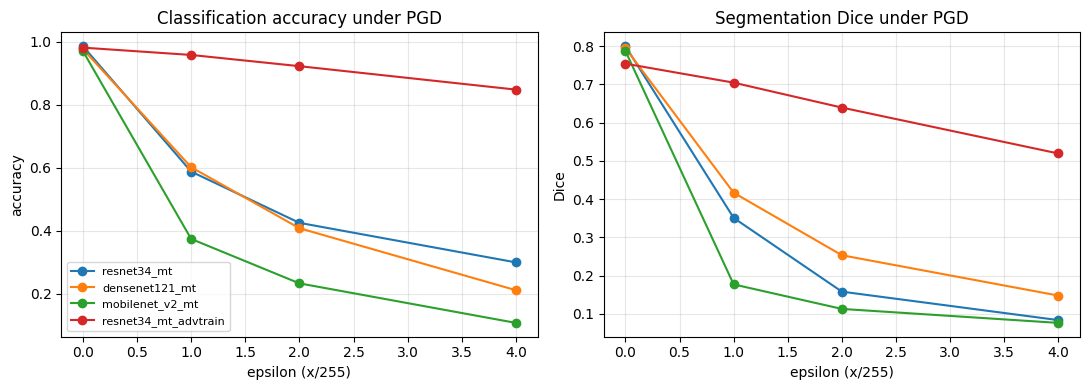

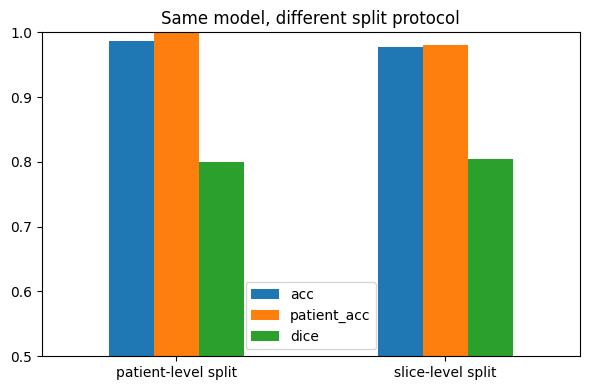

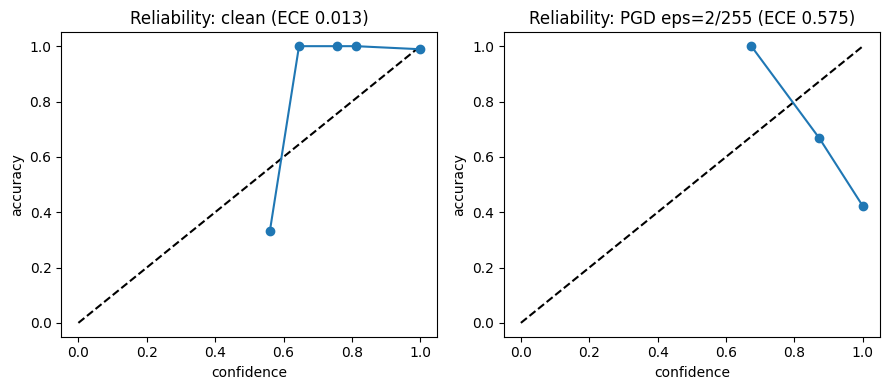

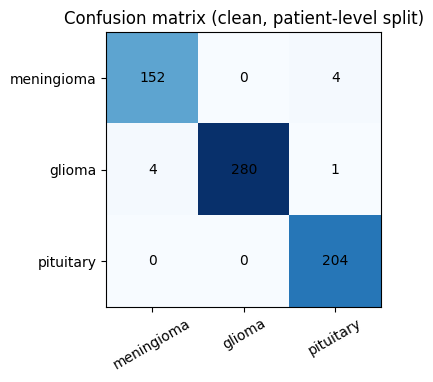

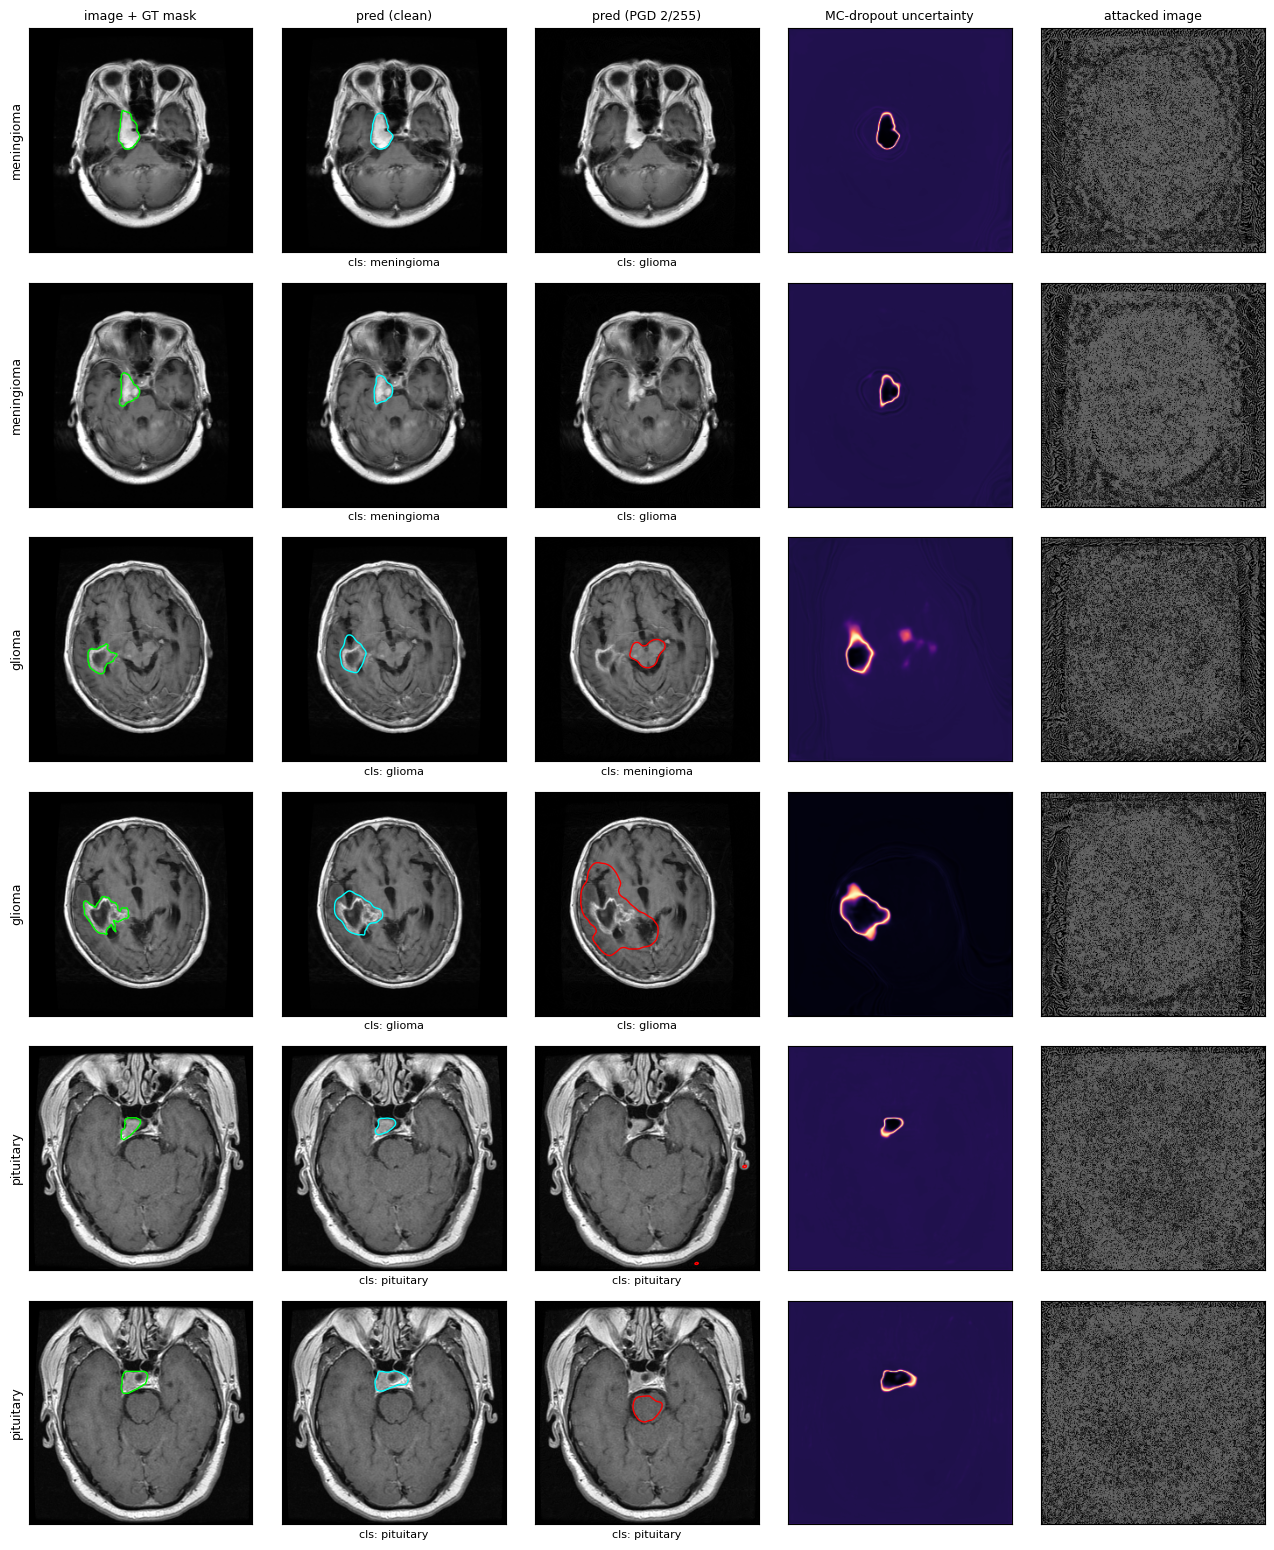


Saved to /kaggle/working/outputs
results_long.csv | uncertainty_and_meta.csv | figs/*.png | ckpt/*.pt | results/*.json


In [16]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / "figs" / name, dpi=150)
    plt.show()


# 9.1 robustness curves
eps_x = [0] + [int(round(e * 255)) for e in CFG["eval_eps"]]

runs_curve = [
    r for r in (
        "resnet34_mt",
        "densenet121_mt",
        "mobilenet_v2_mt",
        "resnet34_mt_advtrain"
    )
    if r in set(df.run)
]

if runs_curve:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for r in runs_curve:
        sub = df[df.run == r].groupby("cond")[["acc", "dice"]].mean()

        conds = ["clean"] + [f"pgd_{e}" for e in eps_x[1:]]

        ax[0].plot(
            eps_x,
            [sub.loc[c, "acc"] for c in conds],
            marker="o",
            label=r
        )

        ax[1].plot(
            eps_x,
            [sub.loc[c, "dice"] for c in conds],
            marker="o",
            label=r
        )

    ax[0].set(
        title="Classification accuracy under PGD",
        xlabel="epsilon (x/255)",
        ylabel="accuracy"
    )

    ax[1].set(
        title="Segmentation Dice under PGD",
        xlabel="epsilon (x/255)",
        ylabel="Dice"
    )

    ax[0].legend(fontsize=8)

    for a in ax:
        a.grid(alpha=.3)

    savefig("robustness_pgd.png")


# 9.2 leakage
if {"resnet34_mt", "resnet34_mt_slicesplit"} <= set(df.run):

    sub = (
        df[df.cond == "clean"]
        .groupby("run")[["acc", "patient_acc", "dice"]]
        .mean()
        .loc[["resnet34_mt", "resnet34_mt_slicesplit"]]
    )

    sub.index = [
        "patient-level split",
        "slice-level split"
    ]

    sub.plot.bar(
        figsize=(6, 4),
        rot=0,
        ylim=(0.5, 1.0)
    )

    plt.title("Same model, different split protocol")

    savefig("leakage.png")


# 9.3 reliability diagram (clean vs PGD) for the main model
key_c = (
    "resnet34_mt",
    CFG["folds_to_run"][0],
    "clean"
)

key_a = (
    "resnet34_mt",
    CFG["folds_to_run"][0],
    "pgd_2"
)

if key_c in ARTS and key_a in ARTS:

    fig, ax = plt.subplots(1, 2, figsize=(9, 4))

    for a, (k, title) in zip(
        ax,
        (
            (key_c, "clean"),
            (key_a, "PGD eps=2/255")
        )
    ):
        P, yy = ARTS[k]

        conf = P.max(1)
        corr = P.argmax(1) == yy

        edges = np.linspace(0, 1, 11)

        xs, accs = [], []

        for lo, hi in zip(edges[:-1], edges[1:]):
            msk = (conf > lo) & (conf <= hi)

            if msk.sum() > 0:
                xs.append(conf[msk].mean())
                accs.append(corr[msk].mean())

        a.plot([0, 1], [0, 1], "k--")
        a.plot(xs, accs, marker="o")

        a.set(
            title=f"Reliability: {title} "
                  f"(ECE {ece_score(P, yy):.3f})",
            xlabel="confidence",
            ylabel="accuracy"
        )

    savefig("reliability.png")


    # Confusion matrix
    cm = confusion_matrix(
        ARTS[key_c][1],
        ARTS[key_c][0].argmax(1),
        labels=[0, 1, 2]
    )

    plt.figure(figsize=(4, 4))

    plt.imshow(cm, cmap="Blues")

    plt.xticks(
        range(3),
        CLASS_NAMES,
        rotation=30
    )

    plt.yticks(
        range(3),
        CLASS_NAMES
    )

    for i in range(3):
        for j in range(3):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.title(
        "Confusion matrix (clean, patient-level split)"
    )

    savefig("confusion_matrix.png")


# 9.4 qualitative examples
if "qual" in ARTS:

    Q = ARTS["qual"]

    n = len(Q["y"])

    fig, ax = plt.subplots(
        n,
        5,
        figsize=(13, 2.6 * n)
    )

    cols = [
        "image + GT mask",
        "pred (clean)",
        "pred (PGD 2/255)",
        "MC-dropout uncertainty",
        "attacked image"
    ]

    for i in range(n):

        # Ground-truth image + mask
        ax[i, 0].imshow(
            Q["x"][i],
            cmap="gray"
        )

        ax[i, 0].contour(
            Q["m"][i],
            levels=[0.5],
            colors="lime",
            linewidths=1
        )

        # FIX: explicitly convert numpy float32 -> int
        true_class = int(Q["y"][i])

        ax[i, 0].set_ylabel(
            f"{CLASS_NAMES[true_class]}",
            fontsize=9
        )


        # Clean prediction
        ax[i, 1].imshow(
            Q["x"][i],
            cmap="gray"
        )

        ax[i, 1].contour(
            Q["seg_clean"][i],
            levels=[0.5],
            colors="cyan",
            linewidths=1
        )

        # FIX: explicitly convert to int
        clean_class = int(Q["cls_clean"][i])

        ax[i, 1].set_xlabel(
            f"cls: {CLASS_NAMES[clean_class]}",
            fontsize=8
        )


        # PGD prediction
        ax[i, 2].imshow(
            Q["x_adv"][i],
            cmap="gray"
        )

        ax[i, 2].contour(
            Q["seg_adv"][i],
            levels=[0.5],
            colors="red",
            linewidths=1
        )

        # FIX: explicitly convert to int
        adv_class = int(Q["cls_adv"][i])

        ax[i, 2].set_xlabel(
            f"cls: {CLASS_NAMES[adv_class]}",
            fontsize=8
        )


        # MC-dropout uncertainty
        ax[i, 3].imshow(
            Q["unc"][i],
            cmap="magma"
        )


        # Difference between clean and attacked image
        ax[i, 4].imshow(
            np.abs(Q["x_adv"][i] - Q["x"][i]) * 50,
            cmap="gray",
            vmin=0,
            vmax=1
        )


        # Remove axes
        for a in ax[i]:
            a.set_xticks([])
            a.set_yticks([])


    # Column titles
    for j, c in enumerate(cols):
        ax[0, j].set_title(
            c,
            fontsize=9
        )

    savefig("qualitative.png")


print("\nSaved to", OUT)

print(
    "results_long.csv | uncertainty_and_meta.csv | "
    "figs/*.png | ckpt/*.pt | results/*.json"
)